# **DecisionTree**

# **1. Decision Tree(CART : Classification and Regression Tree)**

**모델구분**  
- **`Decision Tree`** 모델은 **supervised learning**모델.  
- **prediction/classification이 모두 가능**

**모델 구조 및 특징**  
- 노드단위로 구성되어 나무가 가지를 펼쳐 나가는 듯한 직관적인 모델 구조를 갖는다.  
- 학습데이터를 100% 정확도로 예측/분류가 가능하다.  
- 위 특징으로 인해 모델 구조적으로 overfitting 문제가 있어 가지치기를 통한 해결이 필요하다.  

**학습**  
- 불순도를 기반으로 스무고개 게임을 하듯 여러 개의 hypothesis을 데이터에 반영하고 이를 바탕으로 decision boundary(결정경계)를 생성  
- 결정경계에 속한 데이터를 예측/분류 결과에 사용한다.  

**효과 및 활용**  
- ML, DL모델을 통틀어 예측/분류 결과에 따른 해석이 가장 좋다.  
- 이에 따라 **모델 해석이 필요한 문제/필드에 사용**한다. ex)신용평가, 모델분류  

## **2. 모델구조**
- root node(뿌리노드) : 최상위 노드, 모든 샘플 포함  
- leaf node(잎노드) : 최하위 노드, 여기에 속한 샘플이 모델 예측/분류 결과에 사용  
- node(노드) : 결정경계에 해당하는 모든 영역을 노드로 판단한다.    
- 가지(branch) : 노드를 나누는 기준, 가정, hypothesis  
- 깊이(depth) : 뿌리 노드와 잎 노드 까지의 노드 갯수

<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/27.png">

## **3. 모델학습**
### **3.1 impurity(불순도)**
- **`DecisionTree`** 모델이 데이터를 학습하는 과정에서 사용하는 수치척도   
- 정보화 이론에서 사용하는 Gini index, 혹은 entropy를 사용한다.  
- 결정경계에 포함 된 데이터 중 다른 클래스가 포함 된 경우 불순도가 높은 상태  
- 판단기준은 불순도 값이 0.5에 가까수록 impurity가 높고 0 혹은 1에 가까울 수록 purity(순도)가 높다.  
- 즉, 한 노드의 impurity가 가능한 많이 떨어지도록(순도가 올라가도록, 값이 0으로 수렴하게) 노드를 나눈다.

$$ Gini = 1 - \sum_1^n{(p_i)^2} $$
$$ G_{split} = \sum_1^n \frac{N_i} {N} G_{i'}$$
$$ Entropy = - \sum_1^n{p_ilog(p_i)} $$

### **3.2 Gini index**
위 예시에서 뿌리 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>X < 0
>> True = class1 3개, class2 4개  
$1 - ({3 \over 3+4})^2 - ({4 \over 3+4})^2 = 0.48$  
False = class1 4개, class2 3개  
$1 - ({4 \over 4+3})^2 - ({3 \over 4+3})^2 = 0.48$  
total Gini 계수  
$({7 \over 7+7})0.48 + ({7 \over 7+7})0.48 = 0.52$


위 예시에서 잎 노드 기준 지니계수 계산법  
class1 : 삼각형  
class2 : 동그라미  
>Y < 1
>> True = class1 3개, class2 0개  
$1 - ({3 \over 3})^2 - ({0 \over 3})^2 = 0$  
False = class1 0개, class2 4개  
$1 - ({0 \over 4})^2 - ({4 \over 4})^2 = 0$  
total Gini 계수  
$({3 \over 3+4})0 + ({4 \over 3+4})0 = 0$

위의 예시에서 계산한 total Gini index가 **`DecisionTree`** 모델이 학습을 하는 과정에서 불순도를 참고하는 수치가 되며  
이를 바탕으로 더 나은 선택(곧 gini index를 가장 많이 감소시키는 가정)을 하게 되는 결정경계를 생성한다.  
이를 greedy(탐욕화) 알고리즘이라 한다.

## **4. DecisionTreeClassifier 실습**

In [96]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
# scikit-learn iris 데이터로드 / 로딩 데이터 확인
from sklearn.datasets import load_iris

iris = load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [98]:
# 타겟데이터 분리
# 설명변수 이름 값 feature_names
# 타겟데이터 이름값 target_names
X = pd.DataFrame(iris['data'], columns=iris['feature_names'])
# iris['feature_names'], iris['target_names']
y = pd.DataFrame(iris['target'], columns=['Species'])


In [99]:
# 학습데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# train_test_split 샘플이 랜덤하게 섞여 들어감
# 기본 설정 75:25
# test_size 기본설정 비율을 커스텀 변경 가능 0~1 실수값
# 랜덤성 고정 random_state 난수의 시드값
# stratify
X_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
98,5.1,2.5,3.0,1.1
68,6.2,2.2,4.5,1.5
19,5.1,3.8,1.5,0.3
143,6.8,3.2,5.9,2.3
99,5.7,2.8,4.1,1.3
...,...,...,...,...
37,4.9,3.6,1.4,0.1
79,5.7,2.6,3.5,1.0
33,5.5,4.2,1.4,0.2
94,5.6,2.7,4.2,1.3


In [100]:
# 모델 import
from sklearn.tree import DecisionTreeClassifier

In [101]:
# 모델 생성
dtc = DecisionTreeClassifier(random_state=42)

In [102]:
# 모델 학습
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [103]:
# 모델 예측
y_pred = dtc.predict(X_test)

In [104]:
# 모델 평가
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.80      0.89        15
           2       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



## **5. 분류 모델 평가방법 리뷰**

### **5.1 classification 모델평가**
> 분류모델인 **`DecisionTree`** 모델은 분류모델 평가 지표를 사용하여 모델을 평가한다.  
대표적인 모델평가 함수인 **오차행렬(confusion matrix)** 와 **분류평가표(classification report)** 를 사용한다.

### **5.2 confusion matrix(오차행렬)**  

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/21.png">

TP - True Positive(실제값 1, 예측값 1로 정분류 된 갯수)  
FN - False Negative(실제값 1, 예측값 0으로 오분류 된 갯수)  
FP - Flase Positive(실제값 0, 예측값 1로 오분류 된 갯수)  
TN - True Negative(실제값 0, 예측값 0으로 정분류 된 갯수)

### **5.3 정확도(Accuracy)** - 전체 샘플 중 모델이 바르게 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/22.png">

$${TP + TN \over TP + FN + FP + TN}$$

### **5.4 정밀도(Precision)** - 모델이 positive로 분류한 것 중 실제값이 positive이 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/23.png">

$${TP \over TP + FP}$$

### **5.5 재현율(Recall)** - 실제값이 positive인 것 중 모델이 positive라 분류한 비율
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/24.png">

$${TP \over TP + FN}$$

### **5.6 f1-score** - precision과 recall의 조화평균
<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/25.png">

$${2 * precision * recall \over precision + recall}$$  

## **6. 모델 해석을 위한 시각화 방법**
- **`DecisionTree`** 모델은 모든 Ai 모델을 통틀어 모델 전체 구조에 대한 설명이 모두 가능한 유일한 모델이다.  
- 모델의 최대 강점을 살려 전체 모델 구조에 대한 시각화를 진행한다.  
- `plot_tree()` 함수 활용

[Text(0.3181818181818182, 0.9166666666666666, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]\nclass = setosa'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'petal width (cm) <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]\nclass = versicolor'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6363636363636364, 0.5833333333333334, 'petal width (cm) <= 1.7\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]\nclass = virginica'),
 

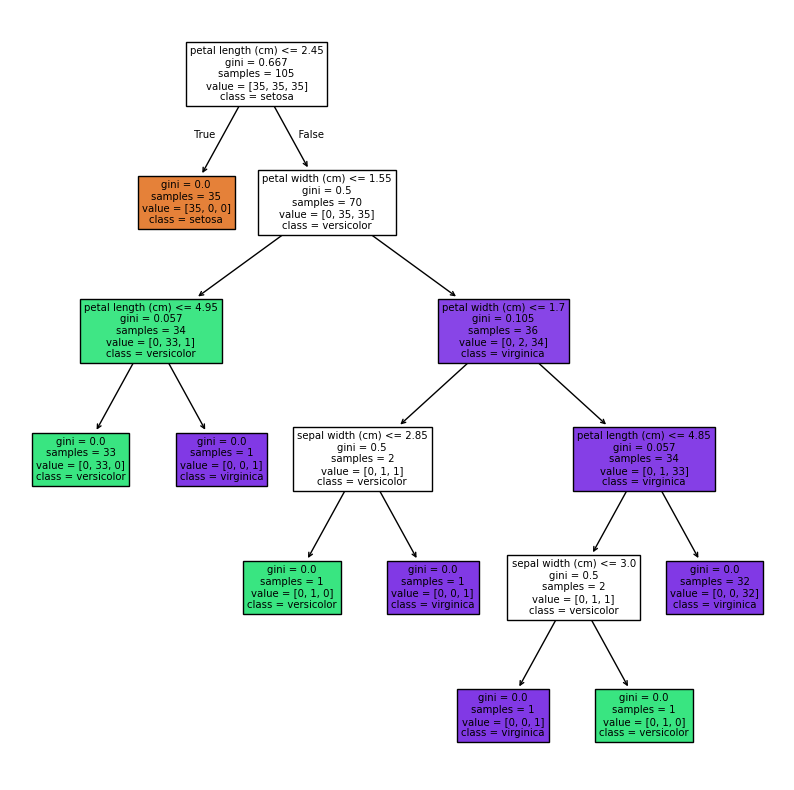

In [105]:
# 모델 시각화
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 10))
plot_tree(dtc, feature_names=iris['feature_names'],
          class_names=iris['target_names'],
          filled=True) # 잎 노드 판단되는 노드에 색구분

## **7. feature importance(변수중요도)**
- 트리 기반 모델은 모델 학습 후 학습에 사용한 어떤 변수가 모델 결과값에 중요하게 사용되었는지 확인이 가능하다.  
- imformation gain값을 정규화
- feature_importances_ 속성값을 통해 트리를 분기하는 과정에서 어떤 변수가 모델의 결과값에 중요하게 사용 되었는지 확인 가능

<BarContainer object of 4 artists>

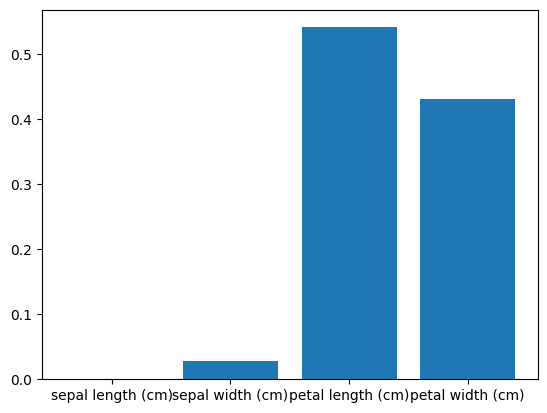

In [106]:
# feature importance 시각화
plt.bar(iris['feature_names'], dtc.feature_importances_)
# 의사결정나무의 feature_importances_는 각 변수가 분류 기준을 만들 때 얼마나 중요하게 사용되었는지를 나타낸다.
# 중요도는 해당 변수로 데이터를 분할했을 때 지니불순도 또는 엔트로피가 얼마나 감소했는지를 기반으로 계산된다.
# 값이 클수록 모델이 해당 변수를 분류 판단에 더 많이 활용했다는 의미이다.

# 주의할 점은 feature importance가 선형모델의 beta coefficient와 다르다는 것이다.
# beta coefficient는 변수가 1 증가할 때 예측값이 어느 방향으로 얼마나 변하는지 해석할 수 있다.
# 반면 feature importance는 변수의 영향 방향을 알려주지 않고, 분류에 기여한 상대적 중요도만 알려준다.
# 따라서 "값이 증가하면 어떤 클래스가 증가한다"가 아니라,
# "해당 변수가 의사결정나무의 분류 기준에서 중요하게 사용되었다"라고 해석해야 한다.

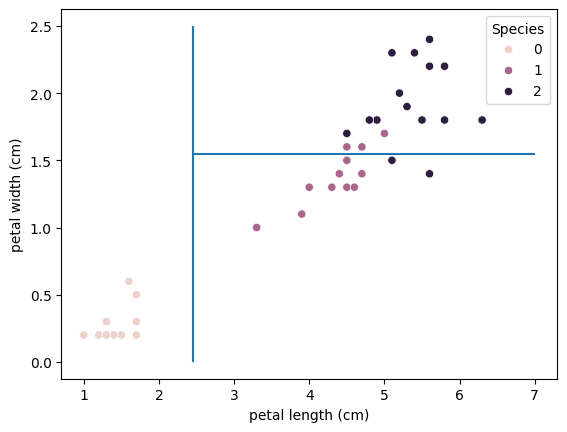

In [107]:
# 트리 구조도에 따라 학습(가정선)과정을 시각화
sns.scatterplot(data=X_test, x=iris['feature_names'][2], y=iris['feature_names'][3], hue=y_test.squeeze()) # target 데이터에 따라 범례 표시 & squeeze() 함수로 (45, 1) -> (45,)로 만들어주기
plt.vlines(2.45, 0, 2.5) # 그려지는 위치, 최소, 최대값 순서대로
plt.hlines(1.55, 2.45, 7)

# **8. 과적합(overfitting)**  
- 학습 데이터로 학습한 모델의 테스트 데이터 예측 성능이 떨어지는 경우  
- 모델이 일반화를 잘 못 시키는 상태. 실제 데이터 예측을 잘 못한다고 해석이 가능합니다.
<div align="center">
  <img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/16.png">
</div>

**overfitting**문제는 머신러닝 모델링에 있어 자주 발생하는 문제로서 모델의 복잡도를 개선하여 해결할 수 있습니다.  

### **8.1 pruning(가지치기)**
- **`Decision Tree`** 는 모든 **모든 잎 노드의 불순도가 0이 되는 순간까지 모델을 성장**시키면서 크기를 키워나간다.  
- 순수 노드로만 이루어진 트리 모델은 **training 데이터** 를 100% 정확도로 맞출 수 있고 이러한 특성 때문에 트리 모델은 **overfitting에 취약**하다.  
- 과적합 방지를 위해서는 **트리의 복잡도를 제어** 할 필요가 있다.

- 과적합 방지를 위한 모델링 파라메터  
> **`max_depth`** : 트리의 최대 깊이  
> `max_leaf_nodes` : 잎 노드의 최대개수  
> `min_sample_leaf` : 잎 노드 구성 최소 샘플 갯수  
> `min_sample_split` : 잎 노드 분지 최소 샘플 갯수

위의 모델플로팅 결과를 바탕으로 적정 복잡도를 지닌 depth를 선택 해준다면 overfitting 된 현재 모델을 개선할 수 있습니다.  
트리 모델의 경우 모델 복잡도를 제어하기 위한 하이퍼 파라메터 튜닝이 필수입니다.

In [108]:
# 모델 생성
dtc = DecisionTreeClassifier(max_depth=3, random_state=42)

In [109]:
# 모델 학습
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [110]:
# 모델 분류 결과값 확인
y_pred = dtc.predict(X_test)

In [111]:
# 평가지표 출력
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.93      0.97        15
           2       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



<BarContainer object of 4 artists>

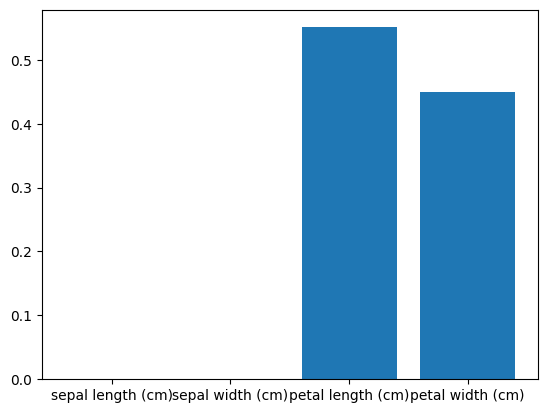

In [112]:
# 변수 중요도 확인
plt.bar(iris['feature_names'], dtc.feature_importances_)

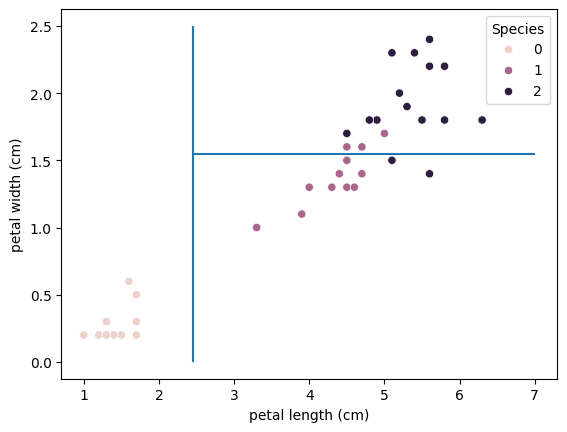

In [113]:
# 모델 구조 시각화
# 트리 구조도에 따라 학습(가정선)과정을 시각화
sns.scatterplot(data=X_test, x=iris['feature_names'][2], y=iris['feature_names'][3], hue=y_test.squeeze()) # hue 타겟데이터에 따라 범례 표시
plt.vlines(2.45, 0, 2.5) # 그려지는 위치, 최소 , 최대값 순서대로
plt.hlines(1.55, 2.45, 7)

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal width (cm) <= 1.55\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal length (cm) <= 4.95\ngini = 0.057\nsamples = 34\nvalue = [0, 33, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 33\nvalue = [0, 33, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.75, 0.375, 'petal width (cm) <= 1.7\ngini = 0.105\nsamples = 36\nvalue = [0, 2, 34]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [0, 1, 1]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.057\nsamples = 34\nvalue = [0, 1, 33]\nclass = virginica')]

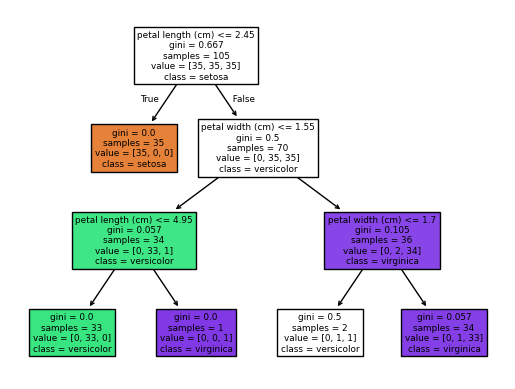

In [114]:
plot_tree(dtc, feature_names=iris['feature_names'],
          class_names=iris['target_names'],
          filled=True)

# **9. Decision Tree Regressor**
- **`Decision Tree`** 모델은 분류 및 예측 모델링에 모두 사용이 가능. 하지만 모델 구분은 필요.  
- 잎 노드에 속한 학습샘플의 값의 평균을 바탕으로 예측값을 결정한다.  
- 회귀모델 평가 방법인 MSE를 사용하여 각 노드에 속한 샘플에 적용하고 오차가 가장 작아지는 가정을 반영하는 방향으로 분기를 수행한다.

$$Cost = \sum_{i \in R_1} (y_i - \hat{y}_{R_1})^2 + \sum_{i \in R_2} (y_i - \hat{y}_{R_2})^2$$

<img src="https://raw.githubusercontent.com/overgroove/LG_electronics_ML/main/image/28.png">

## **10. Decision Tree Regressor 모델 특징**

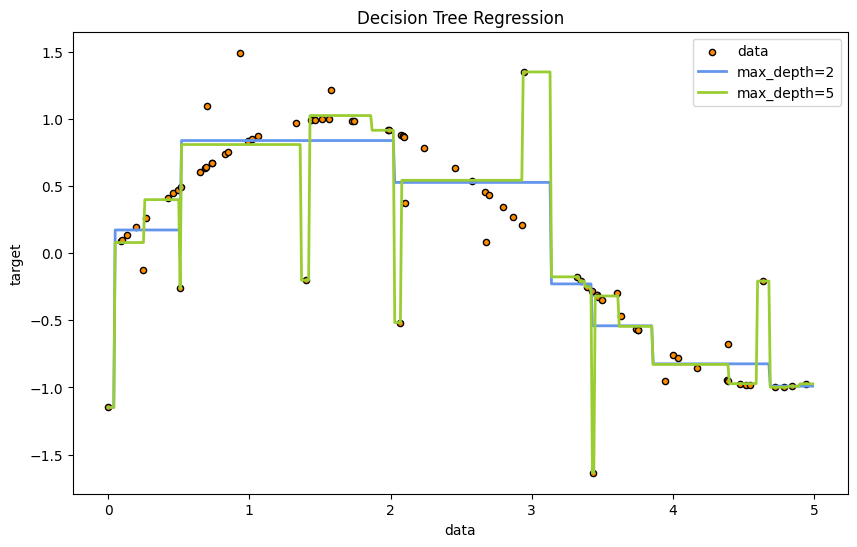

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

regr_1 = DecisionTreeRegressor(max_depth=3)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

X_test_numpy = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test_numpy)
y_2 = regr_2.predict(X_test_numpy)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test_numpy, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test_numpy, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

## **11. Decision Tree Regressor 실습**

In [120]:
# 보스턴 집값 데이터 로딩
df = pd.read_csv("https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/refs/heads/main/data/boston.csv")

# 타겟 데이터 분할
y = df['y']
X = df.drop('y', axis=1)

# 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 모델 import
from sklearn.tree import DecisionTreeRegressor

# 모델 생성
dtr = DecisionTreeRegressor(max_depth=15, random_state=42)

# 모델 학습
dtr.fit(X_train, y_train)

# 모델 예측
y_pred = dtr.predict(X_test)

# 모델 평가지표 출력
from sklearn.metrics import r2_score, root_mean_squared_error
print(r2_score(y_test, y_pred))
print(root_mean_squared_error(y_test, y_pred))

0.8593731880046497
3.2370571637853427


[Text(0.6712136352625088, 0.96875, 'x[5] <= 6.941\nsquared_error = 87.897\nsamples = 354\nvalue = 23.016'),
 Text(0.4049052479739253, 0.90625, 'x[12] <= 14.4\nsquared_error = 41.295\nsamples = 292\nvalue = 20.084'),
 Text(0.5380594416182171, 0.9375, 'True  '),
 Text(0.187673427589852, 0.84375, 'x[7] <= 1.385\nsquared_error = 26.114\nsamples = 178\nvalue = 23.47'),
 Text(0.12003391472868218, 0.78125, 'x[0] <= 10.109\nsquared_error = 91.577\nsamples = 4\nvalue = 44.475'),
 Text(0.1172150281888654, 0.71875, 'squared_error = 0.0\nsamples = 3\nvalue = 50.0'),
 Text(0.12285280126849894, 0.71875, 'squared_error = -0.0\nsamples = 1\nvalue = 27.9'),
 Text(0.2553129404510218, 0.78125, 'x[5] <= 6.543\nsquared_error = 14.233\nsamples = 174\nvalue = 22.987'),
 Text(0.1284905743481325, 0.71875, 'x[12] <= 7.76\nsquared_error = 7.174\nsamples = 133\nvalue = 21.639'),
 Text(0.023255813953488372, 0.65625, 'x[0] <= 0.032\nsquared_error = 2.279\nsamples = 25\nvalue = 23.776'),
 Text(0.0204369274136716, 0.

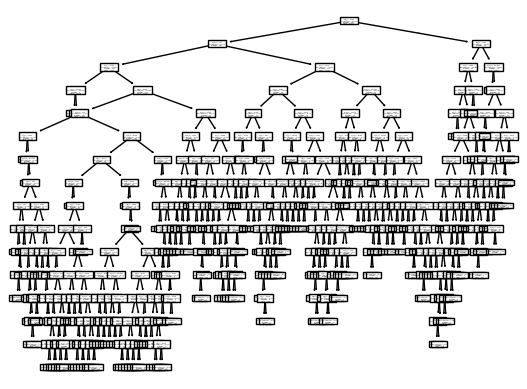

In [121]:
plot_tree(dtr)